# Data Visualization — Plotly
## Interactive Charts
Plotly Express = interactive charts in one line
hover, zoom, filter — no extra code needed

In [1]:
import pandas as pd
import plotly.express as px

df = pd.read_csv("financials_clean2.csv")
df['Profit Margin %'] = round((df['Profit'] / df['Sales']) * 100, 2)

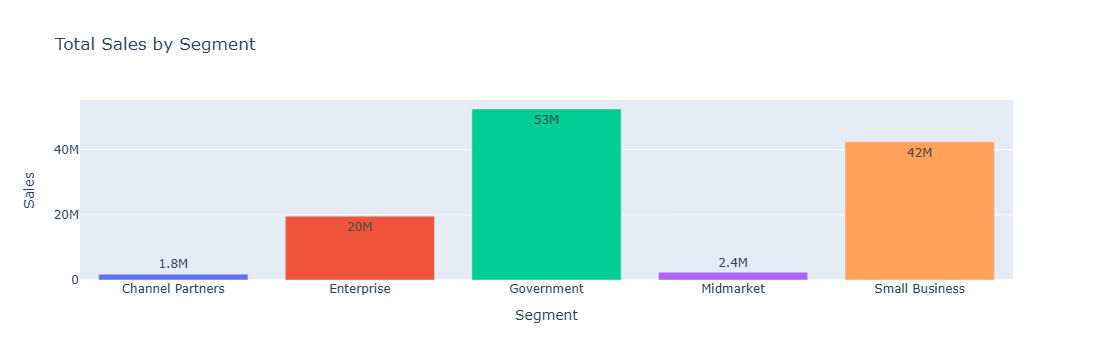

In [2]:
sales_seg = df.groupby('Segment')['Sales'].sum().reset_index()

fig = px.bar(
    sales_seg,
    x='Segment', y='Sales',
    title='Total Sales by Segment',
    color='Segment',
    text_auto='.2s'
)
fig.update_layout(showlegend=False)
fig.show()

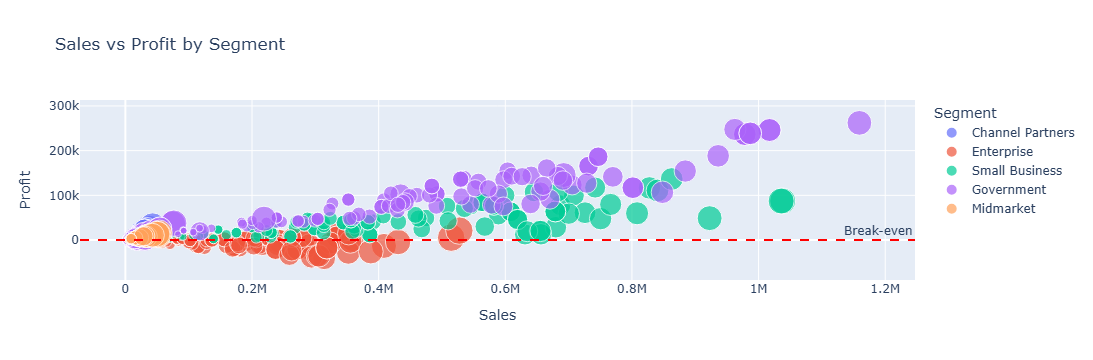

In [3]:
fig = px.scatter(
    df, x='Sales', y='Profit',
    color='Segment',
    size='Units Sold',
    hover_data=['Country', 'Product'],
    title='Sales vs Profit by Segment',
    opacity=0.7
)
fig.add_hline(y=0, line_dash='dash', line_color='red', annotation_text='Break-even')
fig.show()

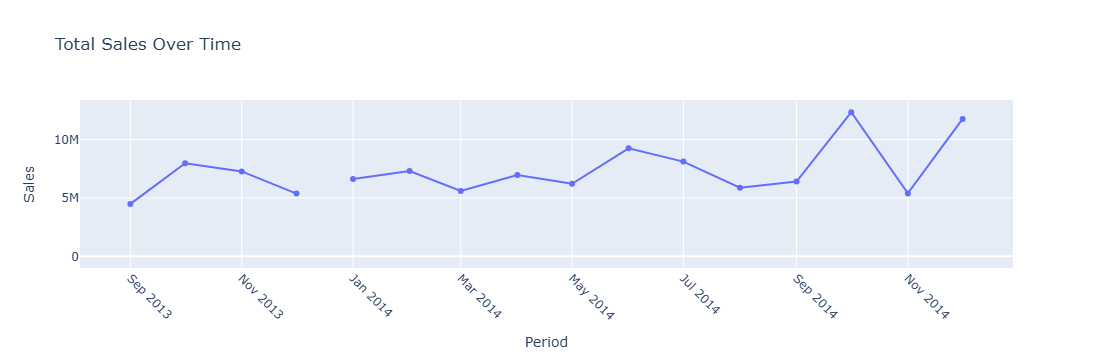

In [4]:
df_time = df.groupby(['Year', 'Month Number'])['Sales'].sum().reset_index()
df_time['Period'] = df_time['Year'].astype(str) + '-' + df_time['Month Number'].astype(str).str.zfill(2)
df_time = df_time.sort_values(['Year', 'Month Number'])

fig = px.line(
    df_time, x='Period', y='Sales',
    title='Total Sales Over Time',
    markers=True
)
fig.update_layout(xaxis_tickangle=45)
fig.show()

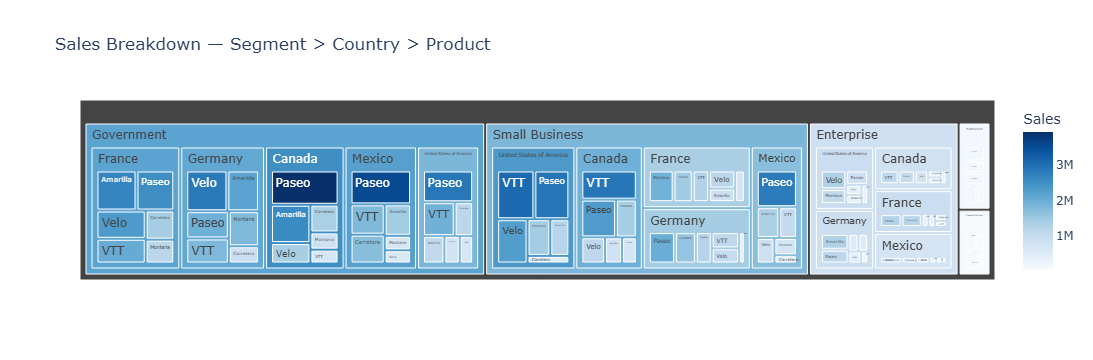

In [5]:
df_tree = df.groupby(['Segment', 'Country', 'Product'])['Sales'].sum().reset_index()

fig = px.treemap(
    df_tree,
    path=['Segment', 'Country', 'Product'],
    values='Sales',
    title='Sales Breakdown — Segment > Country > Product',
    color='Sales',
    color_continuous_scale='Blues'
)
fig.show()

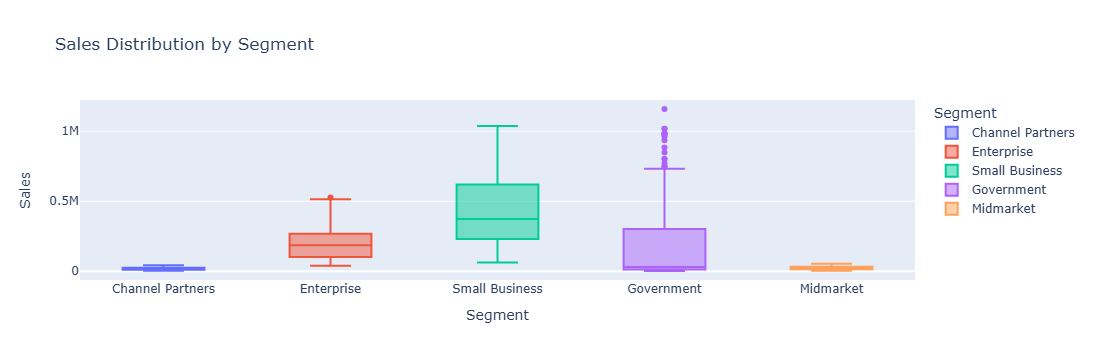

In [6]:
fig = px.box(
    df, x='Segment', y='Sales',
    color='Segment',
    title='Sales Distribution by Segment',
    points='outliers'
)
fig.show()

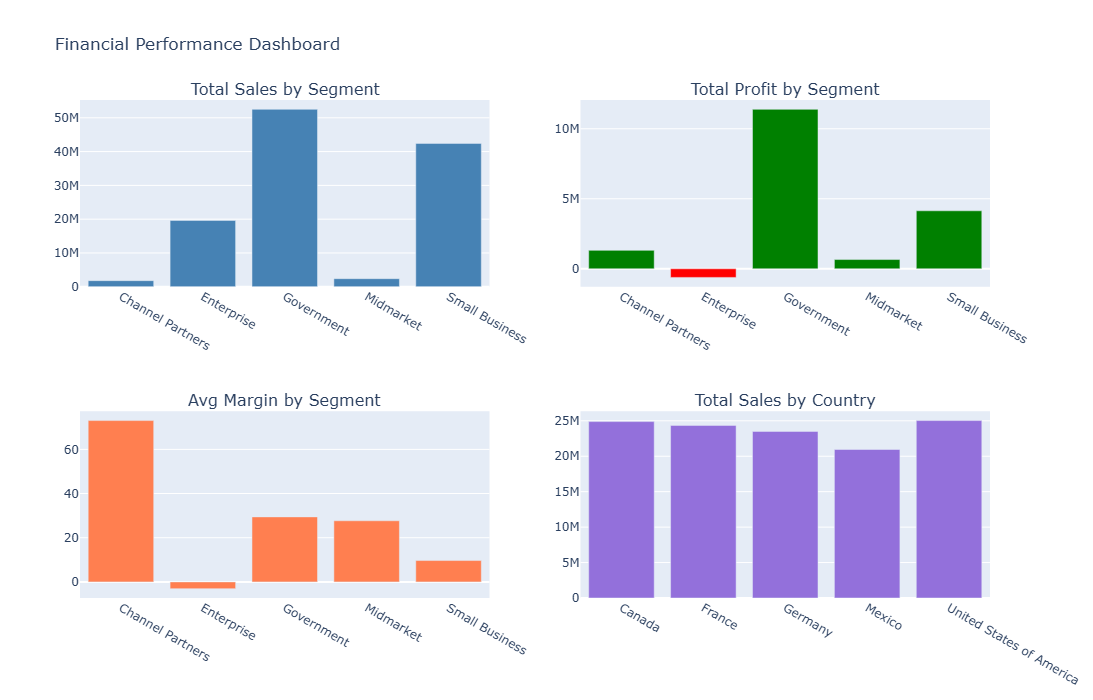

In [7]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

sales_seg = df.groupby('Segment')['Sales'].sum().reset_index()
profit_seg = df.groupby('Segment')['Profit'].sum().reset_index()
margin_seg = df.groupby('Segment')['Profit Margin %'].mean().reset_index()
sales_country = df.groupby('Country')['Sales'].sum().reset_index()

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=['Total Sales by Segment', 'Total Profit by Segment',
                    'Avg Margin by Segment', 'Total Sales by Country']
)

fig.add_trace(go.Bar(x=sales_seg['Segment'], y=sales_seg['Sales'],
                     marker_color='steelblue', name='Sales'), row=1, col=1)
fig.add_trace(go.Bar(x=profit_seg['Segment'], y=profit_seg['Profit'],
                     marker_color=['green' if v > 0 else 'red' for v in profit_seg['Profit']],
                     name='Profit'), row=1, col=2)
fig.add_trace(go.Bar(x=margin_seg['Segment'], y=margin_seg['Profit Margin %'],
                     marker_color='coral', name='Margin'), row=2, col=1)
fig.add_trace(go.Bar(x=sales_country['Country'], y=sales_country['Sales'],
                     marker_color='mediumpurple', name='Country Sales'), row=2, col=2)

fig.update_layout(height=700, title_text='Financial Performance Dashboard',
                  showlegend=False)
fig.show()